<a href="https://colab.research.google.com/github/krithi-ks/PetroVision/blob/main/notebooks/computer-vision/PetroVision_SegFormer_FineTuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CV-SEGFORMER-001 — SegFormer Fine-Tuning

## What this experiment does

This experiment evaluates a pretrained **SegFormer-B0** model fine-tuned for binary petroleum-contamination segmentation on the **LADOS dataset**.

The model is trained to distinguish:

* **Petroleum-related pixels:** Oil, Emulsion, and Sheen
* **Non-petroleum pixels:** Background, Ship, and Oil-platform

The original LADOS semantic-segmentation labels are therefore converted into a binary petroleum-contamination target for PetroVision.

## Model

* Architecture: SegFormer-B0
* Backbone: MiT-B0
* Initialization: ImageNet-pretrained weights
* Framework: Hugging Face Transformers + PyTorch
* Task: Binary semantic segmentation

## Training configuration

* Dataset: LADOS
* Training images: 2,370
* Validation images: 675
* Test images: 343
* Input resolution: 256 × 256
* Batch size: 16
* Epochs: 20
* Optimizer: Adam
* Learning rate: 1 × 10⁻⁴
* Loss: BCE + Dice Loss
* Prediction threshold: 0.5
* Training augmentation: enabled
* Device: CUDA GPU when available

## Evaluation metrics

The test set is evaluated using:

* IoU
* Dice coefficient
* Precision
* Recall
* Pixel accuracy

Pixel-level TP, FP, FN, and TN counts are also recorded for error analysis.

## Important experimental rule

The test set is used only for final evaluation. Model selection during training is based on validation loss.

All values shown in the following visualizations are loaded from the saved experiment outputs rather than manually entered.

## Saved outputs

* Model checkpoint: `cv_segformer_001_best.pt`
* Training history: `training_history.json`
* Test metrics: `test_metrics.json`

## Scope and limitation

The results represent the performance of this SegFormer configuration on the evaluated LADOS test set. They should not be interpreted as chemical identification of petroleum or as measurement of oil concentration, thickness, or volume.

The segmentation output identifies visible petroleum-related regions in RGB imagery according to the dataset labels.


## Install Dependencies and Imports





In [1]:
!pip install -q transformers

In [2]:
import os
import sys
import json
import time
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from pathlib import Path
from torch.utils.data import DataLoader
from transformers import SegformerForSemanticSegmentation

## Project Setup

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [4]:
!git clone https://github.com/krithi-ks/PetroVision.git /content/PetroVision
%cd /content/PetroVision

from pathlib import Path

print("Project root:", Path.cwd())
print("\nProject files:")
for item in sorted(Path(".").iterdir()):
    print(" -", item.name)

Cloning into '/content/PetroVision'...
remote: Enumerating objects: 263, done.
remote: Counting objects: 100% (29/29), done.
remote: Compressing objects: 100% (25/25), done.
remote: Total 263 (delta 6), reused 17 (delta 4), pack-reused 234 (from 1)
Receiving objects: 100% (263/263), 80.00 MiB | 14.71 MiB/s, done.
Resolving deltas: 100% (83/83), done.
Updating files: 100% (68/68), done.
/content/PetroVision
Project root: /content/PetroVision

Project files:
 - .git
 - .gitignore
 - README.md
 - app
 - data
 - docs
 - models
 - notebooks
 - references
 - reports
 - requirements.txt
 - results
 - src


In [5]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [6]:
PROJECT_DIR = Path("/content/PetroVision")

RESULTS_DIR = Path(
    "/content/drive/MyDrive/PetroVision/results/cv_segformer_001"
)

MODEL_DIR = Path(
    "/content/drive/MyDrive/PetroVision/models"
)

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("Project:", PROJECT_DIR)
print("Results:", RESULTS_DIR)

Project: /content/PetroVision
Results: /content/drive/MyDrive/PetroVision/results/cv_segformer_001


In [7]:
from pathlib import Path
import zipfile

ZIP_PATH = Path(
    "/content/drive/MyDrive/PetroVision/datasets/"
    "PetroVision.v1i.png-mask-semantic.zip"
)

EXTRACT_DIR = Path("/content/PetroVision/data/lados")

if not ZIP_PATH.exists():
    raise FileNotFoundError(f"Dataset ZIP not found: {ZIP_PATH}")

EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("Dataset extracted to:", EXTRACT_DIR)


Dataset extracted to: /content/PetroVision/data/lados


In [8]:
from src.vision.lados_dataset import LADOSDataset
from src.vision.segmentation_loss import BCEDiceLoss

DATASET_ROOT = os.path.join(PROJECT_DIR, "data", "lados")

print("Dataset exists:", os.path.exists(DATASET_ROOT))
print("Source module loaded successfully.")

Dataset exists: True
Source module loaded successfully.


## Data Set

In [9]:
from src.vision.lados_dataset import LADOSDataset

DATASET_ROOT = PROJECT_DIR / "data" / "lados"

train_dataset = LADOSDataset(
    root_dir=DATASET_ROOT,
    split="train",
    image_size=(256, 256),
    augment=True
)

val_dataset = LADOSDataset(
    root_dir=DATASET_ROOT,
    split="valid",
    image_size=(256, 256),
    augment=False
)

test_dataset = LADOSDataset(
    root_dir=DATASET_ROOT,
    split="test",
    image_size=(256, 256),
    augment=False
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 2370
Validation: 675
Test: 343


## Data Loaders

In [10]:
BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

## Load Pretrained SegFormer-B0 model

In [11]:
MODEL_NAME = "nvidia/mit-b0"

model = SegformerForSemanticSegmentation.from_pretrained(
    MODEL_NAME,
    num_labels=1,
    ignore_mismatched_sizes=True
)

model = model.to(device)

print("Model:", MODEL_NAME)
print(
    "Trainable parameters:",
    sum(p.numel() for p in model.parameters() if p.requires_grad)
)

config.json:   0%|          | 0.00/70.0k [00:00<?, ?B/s]

[transformers] You passed `num_labels=1` which is incompatible to the `id2label` map of length `1000`.


pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 14.4MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b0
Key                                                     | Status     | 
--------------------------------------------------------+------------+-
classifier.bias                                         | UNEXPECTED | 
classifier.weight                                       | UNEXPECTED | 
decode_head.linear_projections.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.linear_projections.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.batch_norm.bias                             | MISSING    | 
decode_head.classifier.weight                           | MISSING    | 
decode_head.batch_norm.weight                           | MISSING    | 
decode_head.batch_norm.running_var                      | MISSING    | 
decode_head.batch_norm.running_mean                     | MISSING    | 
decode_head.linear_fuse.weight                          | MISSING    | 
decode_head.batch_norm.num_batches_tracked              

Model: nvidia/mit-b0
Trainable parameters: 3714401


## Model Loss & Optimizer

In [12]:
criterion = BCEDiceLoss()

LEARNING_RATE = 1e-4

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

print("Learning rate:", LEARNING_RATE)

Learning rate: 0.0001


## Output Size

In [13]:
import torch.nn.functional as F

def get_segformer_logits(model_output, target_size):
    logits = model_output.logits

    logits = F.interpolate(
        logits,
        size=target_size,
        mode="bilinear",
        align_corners=False
    )

    return logits

## Test one batch

In [14]:
model.train()

images, masks = next(iter(train_loader))

images = images.to(device, non_blocking=True)
masks = masks.to(device, non_blocking=True)

optimizer.zero_grad()

outputs = model(pixel_values=images)

logits = get_segformer_logits(
    outputs,
    masks.shape[-2:]
)

print("Input:", images.shape)
print("Mask:", masks.shape)
print("SegFormer logits:", logits.shape)

loss = criterion(logits, masks)

print("Test loss:", loss.item())

Input: torch.Size([16, 3, 256, 256])
Mask: torch.Size([16, 1, 256, 256])
SegFormer logits: torch.Size([16, 1, 256, 256])
Test loss: 0.6243598461151123


In [15]:
# Optimizer/model sanity check

model.train()

images, masks = next(iter(train_loader))
images = images.to(device, non_blocking=True)
masks = masks.to(device, non_blocking=True)

optimizer.zero_grad()

before = {
    name: param.detach().clone()
    for name, param in model.named_parameters()
    if param.requires_grad
}

outputs = model(pixel_values=images)

logits = get_segformer_logits(
    outputs,
    masks.shape[-2:]
)

loss = criterion(logits, masks)
loss.backward()

optimizer.step()

max_update = 0.0

for name, param in model.named_parameters():
    if param.requires_grad:
        update = torch.max(
            torch.abs(param.detach() - before[name])
        ).item()
        max_update = max(max_update, update)

print("Loss:", loss.item())
print("Maximum parameter update:", max_update)
print("Optimizer learning rate:", optimizer.param_groups[0]["lr"])

Loss: 0.6218034029006958
Maximum parameter update: 0.00010013580322265625
Optimizer learning rate: 0.0001


In [16]:
# Fresh model and optimizer for the official CV-SEGFORMER-001 experiment

model = SegformerForSemanticSegmentation.from_pretrained(
    MODEL_NAME,
    num_labels=1,
    id2label={0: "petroleum"},
    label2id={"petroleum": 0},
    ignore_mismatched_sizes=True
).to(device)

criterion = BCEDiceLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

print("Fresh SegFormer model created.")
print(
    "Trainable parameters:",
    sum(p.numel() for p in model.parameters() if p.requires_grad)
)
print("Learning rate:", optimizer.param_groups[0]["lr"])

[transformers] You passed `num_labels=1` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b0
Key                                                     | Status     | 
--------------------------------------------------------+------------+-
classifier.bias                                         | UNEXPECTED | 
classifier.weight                                       | UNEXPECTED | 
decode_head.linear_projections.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.linear_projections.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.batch_norm.bias                             | MISSING    | 
decode_head.classifier.weight                           | MISSING    | 
decode_head.batch_norm.weight                           | MISSING    | 
decode_head.batch_norm.running_var                      | MISSING    | 
decode_head.batch_norm.running_mean                     | MISSING    | 
decode_head.linear_fuse.weight                          | MISSING    | 
decode_head.batch_norm.num_batches_tracked              

Fresh SegFormer model created.
Trainable parameters: 3714401
Learning rate: 0.0001


In [18]:
EPOCHS = 20

train_history = []
validation_history = []

best_val_loss = float("inf")
best_epoch = 0

CHECKPOINT_PATH = MODEL_DIR / "cv_segformer_001_best.pt"
HISTORY_PATH = RESULTS_DIR / "training_history.json"

for epoch in range(EPOCHS):

    # -------------------------
    # Training
    # -------------------------
    model.train()

    train_loss_sum = 0.0
    train_samples = 0

    for images, masks in train_loader:

        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(pixel_values=images)

        logits = get_segformer_logits(
            outputs,
            masks.shape[-2:]
        )

        loss = criterion(logits, masks)

        loss.backward()
        optimizer.step()

        batch_size = images.size(0)

        train_loss_sum += loss.item() * batch_size
        train_samples += batch_size

    train_loss = train_loss_sum / train_samples

    # -------------------------
    # Validation
    # -------------------------
    model.eval()

    val_loss_sum = 0.0
    val_samples = 0

    with torch.no_grad():

        for images, masks in val_loader:

            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            outputs = model(pixel_values=images)

            logits = get_segformer_logits(
                outputs,
                masks.shape[-2:]
            )

            loss = criterion(logits, masks)

            batch_size = images.size(0)

            val_loss_sum += loss.item() * batch_size
            val_samples += batch_size

    val_loss = val_loss_sum / val_samples

    train_history.append(train_loss)
    validation_history.append(val_loss)

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.6f} | "
        f"Validation Loss: {val_loss:.6f}"
    )

    # -------------------------
    # Save best checkpoint
    # -------------------------
    if val_loss < best_val_loss:

        best_val_loss = val_loss
        best_epoch = epoch + 1

        torch.save(
            {
                "experiment_id": "CV-SEGFORMER-001",
                "model_name": MODEL_NAME,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "epoch": best_epoch,
                "validation_loss": best_val_loss,
            },
            CHECKPOINT_PATH
        )

# Save training history
history = {
    "train_loss": train_history,
    "validation_loss": validation_history,
    "best_epoch": best_epoch,
    "best_validation_loss": best_val_loss,
}

with open(HISTORY_PATH, "w") as f:
    json.dump(history, f, indent=2)

print("\nTraining complete.")
print("Best epoch:", best_epoch)
print("Best validation loss:", best_val_loss)
print("Checkpoint:", CHECKPOINT_PATH)
print("History:", HISTORY_PATH)

Epoch 01/20 | Train Loss: 0.397505 | Validation Loss: 0.335368
Epoch 02/20 | Train Loss: 0.312289 | Validation Loss: 0.309661
Epoch 03/20 | Train Loss: 0.286070 | Validation Loss: 0.304260
Epoch 04/20 | Train Loss: 0.264261 | Validation Loss: 0.278293
Epoch 05/20 | Train Loss: 0.249120 | Validation Loss: 0.268253
Epoch 06/20 | Train Loss: 0.232105 | Validation Loss: 0.264706
Epoch 07/20 | Train Loss: 0.224409 | Validation Loss: 0.273956
Epoch 08/20 | Train Loss: 0.215016 | Validation Loss: 0.269463
Epoch 09/20 | Train Loss: 0.205371 | Validation Loss: 0.250131
Epoch 10/20 | Train Loss: 0.206463 | Validation Loss: 0.257674
Epoch 11/20 | Train Loss: 0.203470 | Validation Loss: 0.254360
Epoch 12/20 | Train Loss: 0.192352 | Validation Loss: 0.249584
Epoch 13/20 | Train Loss: 0.188524 | Validation Loss: 0.253940
Epoch 14/20 | Train Loss: 0.195429 | Validation Loss: 0.255938
Epoch 15/20 | Train Loss: 0.184968 | Validation Loss: 0.260638
Epoch 16/20 | Train Loss: 0.177776 | Validation Loss: 0

In [19]:
# Load the best SegFormer checkpoint

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=device,
    weights_only=False
)

model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(device)
model.eval()

print("Loaded checkpoint from epoch:", checkpoint["epoch"])
print("Best validation loss:", checkpoint["validation_loss"])

Loaded checkpoint from epoch: 12
Best validation loss: 0.24958371029959783


In [21]:
# Test-set evaluation

TP = 0
FP = 0
FN = 0
TN = 0

inference_times = []

with torch.no_grad():

    for images, masks in test_loader:

        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        start_time = time.perf_counter()

        outputs = model(pixel_values=images)

        logits = get_segformer_logits(
            outputs,
            masks.shape[-2:]
        )

        probabilities = torch.sigmoid(logits)
        predictions = (probabilities >= 0.5).float()

        inference_times.append(
            time.perf_counter() - start_time
        )

        TP += ((predictions == 1) & (masks == 1)).sum().item()
        FP += ((predictions == 1) & (masks == 0)).sum().item()
        FN += ((predictions == 0) & (masks == 1)).sum().item()
        TN += ((predictions == 0) & (masks == 0)).sum().item()


epsilon = 1e-8

iou = TP / (TP + FP + FN + epsilon)

dice = (
    2 * TP /
    (2 * TP + FP + FN + epsilon)
)

precision = TP / (TP + FP + epsilon)

recall = TP / (TP + FN + epsilon)

accuracy = (
    (TP + TN) /
    (TP + TN + FP + FN + epsilon)
)

metrics = {
    "IoU": iou,
    "Dice": dice,
    "Precision": precision,
    "Recall": recall,
    "Accuracy": accuracy,
    "TP": TP,
    "FP": FP,
    "FN": FN,
    "TN": TN,
}

print("Test Metrics")
print("-" * 40)

for key, value in metrics.items():
    print(f"{key}: {value:.6f}" if isinstance(value, float) else f"{key}: {value}")

print("\nAverage batch inference time:",
      np.mean(inference_times))

Test Metrics
----------------------------------------
IoU: 0.814282
Dice: 0.897636
Precision: 0.901561
Recall: 0.893745
Accuracy: 0.891464
TP: 10697143
FP: 1167997
FN: 1271760
TN: 9341948

Average batch inference time: 0.025893848272765106


In [22]:
import json
from pathlib import Path

metrics_path = RESULTS_DIR / "test_metrics.json"

with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)

print("Saved:", metrics_path)

Saved: /content/drive/MyDrive/PetroVision/results/cv_segformer_001/test_metrics.json


In [23]:
summary = {
    "experiment_id": "CV-SEGFORMER-001",
    "what_was_tested": "Pretrained SegFormer-B0 fine-tuned on LADOS",
    "architecture": "SegFormer",
    "variant": "B0",
    "pretrained_model": MODEL_NAME,
    "dataset": "LADOS",
    "train_samples": len(train_dataset),
    "validation_samples": len(val_dataset),
    "test_samples": len(test_dataset),
    "input_size": [256, 256],
    "loss": "BCE + Dice",
    "optimizer": "Adam",
    "learning_rate": LEARNING_RATE,
    "epochs": EPOCHS,
    "best_epoch": checkpoint["epoch"],
    "best_validation_loss": checkpoint["validation_loss"],
    "test_metrics": metrics,
    "average_batch_inference_time_seconds": float(np.mean(inference_times)),
    "limitation": (
        "Results are specific to the LADOS dataset, "
        "pretrained initialization, architecture configuration, "
        "and training setup."
    )
}

summary_path = RESULTS_DIR / "experiment_summary.json"

with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

print("Saved:", summary_path)

Saved: /content/drive/MyDrive/PetroVision/results/cv_segformer_001/experiment_summary.json


In [25]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go

RESULTS_DIR = "/content/drive/MyDrive/PetroVision/results/cv_segformer_001"

with open(f"{RESULTS_DIR}/training_history.json", "r") as f:
    history = json.load(f)

with open(f"{RESULTS_DIR}/test_metrics.json", "r") as f:
    metrics = json.load(f)

print("Experiment: CV-SEGFORMER-001")
print("Results loaded successfully.")
print("Available metric keys:", list(metrics.keys()))

Experiment: CV-SEGFORMER-001
Results loaded successfully.
Available metric keys: ['IoU', 'Dice', 'Precision', 'Recall', 'Accuracy', 'TP', 'FP', 'FN', 'TN']


## Training Behaviour

This visualization answers:

> **Did the SegFormer model learn during fine-tuning, and when was the best validation performance observed?**

Training and validation loss are plotted across all epochs. The epoch with the lowest validation loss is highlighted as the selected checkpoint.


In [26]:
import plotly.graph_objects as go

with open(HISTORY_PATH, "r") as f:
    history = json.load(f)

epochs = list(range(1, len(history["train_loss"]) + 1))

fig = go.Figure()
train_loss = history["train_loss"]
val_loss = history["validation_loss"]

epochs = np.arange(1, len(train_loss) + 1)
best_epoch = int(np.argmin(val_loss)) + 1
best_val_loss = val_loss[best_epoch - 1]

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=epochs,
        y=train_loss,
        mode="lines+markers",
        name="Training Loss",
        hovertemplate="Epoch %{x}<br>Training Loss: %{y:.6f}<extra></extra>"
    )
)

fig.add_trace(
    go.Scatter(
        x=epochs,
        y=val_loss,
        mode="lines+markers",
        name="Validation Loss",
        hovertemplate="Epoch %{x}<br>Validation Loss: %{y:.6f}<extra></extra>"
    )
)

fig.add_trace(
    go.Scatter(
        x=[best_epoch],
        y=[best_val_loss],
        mode="markers",
        marker=dict(size=12),
        name=f"Best Epoch ({best_epoch})",
        hovertemplate=(
            f"Best Epoch: {best_epoch}"
            f"<br>Validation Loss: {best_val_loss:.6f}"
            "<extra></extra>"
        )
    )
)

fig.update_layout(
    title="SegFormer Training Behaviour",
    xaxis_title="Epoch",
    yaxis_title="Loss",
    hovermode="x unified",
    template="plotly_white"
)

fig.show()

print(f"Best epoch: {best_epoch}")
print(f"Best validation loss: {best_val_loss:.6f}")
fig.add_trace(
    go.Scatter(
        x=epochs,
        y=history["train_loss"],
        mode="lines+markers",
        name="Training Loss"
    )
)

fig.add_trace(
    go.Scatter(
        x=epochs,
        y=history["validation_loss"],
        mode="lines+markers",
        name="Validation Loss"
    )
)

best_epoch = history["best_epoch"]
best_val = history["best_validation_loss"]

fig.add_trace(
    go.Scatter(
        x=[best_epoch],
        y=[best_val],
        mode="markers",
        name="Best Validation Loss",
        marker=dict(size=12)
    )
)

fig.update_layout(
    title="CV-SEGFORMER-001 Training Behaviour",
    xaxis_title="Epoch",
    yaxis_title="BCE + Dice Loss",
    hovermode="x unified"
)

fig.show()

Best epoch: 12
Best validation loss: 0.249584


## Test-set Segmentation Performance

This visualization answers:

> **How well did SegFormer segment petroleum-related regions on unseen test images?**

The metrics are loaded directly from the saved test evaluation:

* IoU measures overlap between predicted and ground-truth petroleum regions.
* Dice measures segmentation agreement.
* Precision measures how many predicted petroleum pixels were correct.
* Recall measures how many ground-truth petroleum pixels were detected.
* Accuracy measures overall pixel classification accuracy.


In [27]:
metric_names = ["IoU", "Dice", "Precision", "Recall", "Accuracy"]

metric_values = [
    metrics["IoU"],
    metrics["Dice"],
    metrics["Precision"],
    metrics["Recall"],
    metrics["Accuracy"],
]

metric_df = pd.DataFrame({
    "Metric": metric_names,
    "Value": metric_values
})

fig = go.Figure(
    go.Bar(
        x=metric_df["Metric"],
        y=metric_df["Value"],
        text=[f"{v:.4f}" for v in metric_df["Value"]],
        textposition="outside",
        hovertemplate="%{x}<br>Value: %{y:.6f}<extra></extra>"
    )
)

fig.update_layout(
    title="SegFormer Test-set Performance",
    xaxis_title="Metric",
    yaxis_title="Score",
    yaxis=dict(range=[0, 1]),
    template="plotly_white"
)

fig.show()

display(
    metric_df.style.format({"Value": "{:.6f}"})
)

,Metric,Value
0,IoU,0.814282
1,Dice,0.897636
2,Precision,0.901561
3,Recall,0.893745
4,Accuracy,0.891464


## Pixel-level Error Analysis

This visualization answers:

> **Where did the SegFormer model make correct and incorrect pixel-level predictions?**

The confusion components are obtained from the saved test evaluation:

* **TP:** petroleum pixels correctly detected
* **FP:** non-petroleum pixels incorrectly predicted as petroleum
* **FN:** petroleum pixels missed by the model
* **TN:** non-petroleum pixels correctly identified

These values provide additional context for interpreting precision, recall, and segmentation quality.


In [28]:
confusion_names = ["True Positive", "False Positive", "False Negative", "True Negative"]

confusion_values = [
    metrics["TP"],
    metrics["FP"],
    metrics["FN"],
    metrics["TN"],
]

confusion_df = pd.DataFrame({
    "Category": confusion_names,
    "Pixel Count": confusion_values
})

fig = go.Figure(
    go.Bar(
        x=confusion_df["Category"],
        y=confusion_df["Pixel Count"],
        text=[f"{v:,}" for v in confusion_df["Pixel Count"]],
        textposition="outside",
        hovertemplate="%{x}<br>Pixels: %{y:,}<extra></extra>"
    )
)

fig.update_layout(
    title="SegFormer Pixel-level Error Analysis",
    xaxis_title="Prediction Category",
    yaxis_title="Number of Pixels",
    template="plotly_white"
)

fig.show()

display(confusion_df)

,Category,Pixel Count
0,True Positive,10697143
1,False Positive,1167997
2,False Negative,1271760
3,True Negative,9341948


## Qualitative Segmentation Results

Quantitative metrics alone do not show how the model behaves visually.

This section compares:

1. **Original image**
2. **Ground-truth petroleum mask**
3. **SegFormer prediction**
4. **Prediction overlay**

The prediction is generated from the saved best SegFormer checkpoint using the LADOS test set.

This provides a visual assessment of whether the model correctly captures the shape and location of visible petroleum-related regions.


In [31]:
import torch
from transformers import SegformerForSemanticSegmentation

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MODEL_NAME = "nvidia/mit-b0"

CHECKPOINT_PATH = (
    "/content/drive/MyDrive/PetroVision/models/"
    "cv_segformer_001_best.pt"
)

# Create the same SegFormer architecture used for training
model = SegformerForSemanticSegmentation.from_pretrained(
    MODEL_NAME,
    num_labels=1,
    ignore_mismatched_sizes=True
)

# Load PetroVision training checkpoint
checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=DEVICE
)

# The saved file contains a complete training checkpoint.
# We need only the trained model parameters.
model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(DEVICE)
model.eval()

print("SegFormer checkpoint loaded successfully.")
print("Model:", MODEL_NAME)
print("Device:", DEVICE)
print("Checkpoint epoch:", checkpoint["epoch"])
print("Validation loss:", checkpoint["validation_loss"])

[transformers] You passed `num_labels=1` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b0
Key                                                     | Status     | 
--------------------------------------------------------+------------+-
classifier.bias                                         | UNEXPECTED | 
classifier.weight                                       | UNEXPECTED | 
decode_head.linear_projections.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.linear_projections.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.batch_norm.bias                             | MISSING    | 
decode_head.classifier.weight                           | MISSING    | 
decode_head.batch_norm.weight                           | MISSING    | 
decode_head.batch_norm.running_var                      | MISSING    | 
decode_head.batch_norm.running_mean                     | MISSING    | 
decode_head.linear_fuse.weight                          | MISSING    | 
decode_head.batch_norm.num_batches_tracked              

SegFormer checkpoint loaded successfully.
Model: nvidia/mit-b0
Device: cuda
Checkpoint epoch: 12
Validation loss: 0.24958371029959783


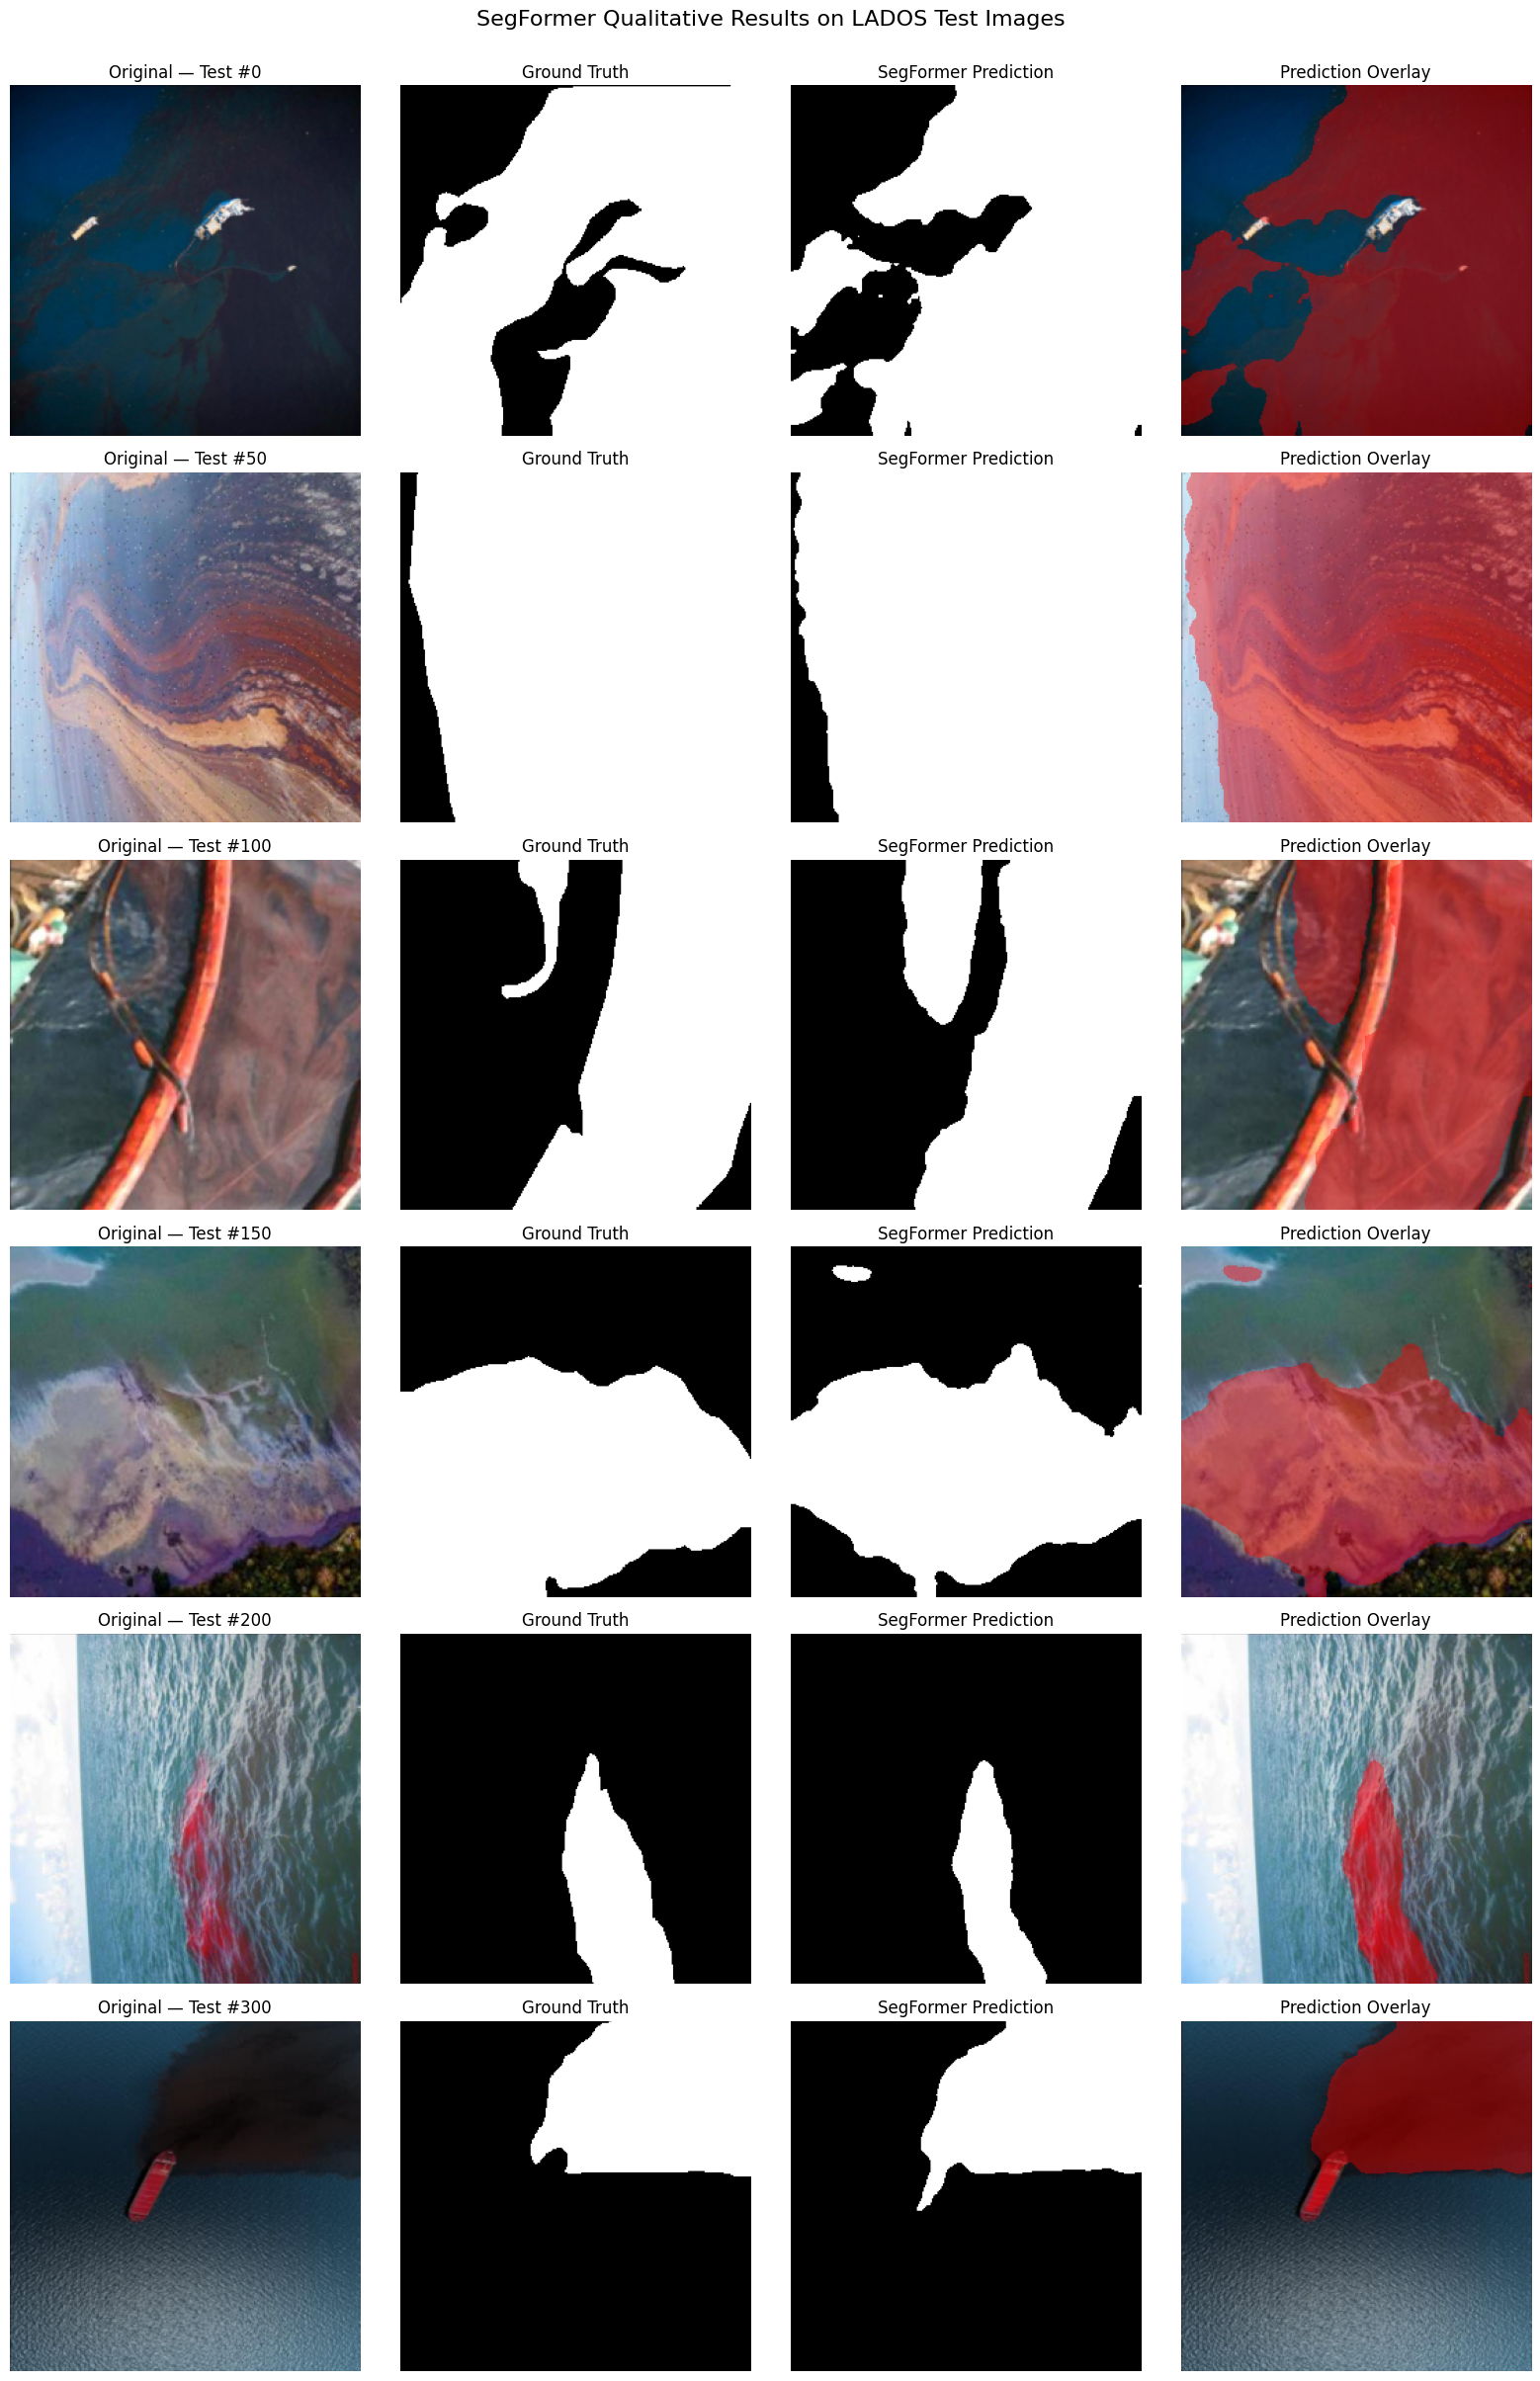

In [33]:
# Visualize multiple LADOS test samples
# Fixed indices make the visualization reproducible.

sample_indices = [0, 50, 100, 150, 200, 300]

fig, axes = plt.subplots(
    len(sample_indices),
    4,
    figsize=(16, 4 * len(sample_indices))
)

for row, sample_index in enumerate(sample_indices):

    image_tensor, mask_tensor = test_dataset[sample_index]

    input_tensor = image_tensor.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        outputs = model(pixel_values=input_tensor)
        logits = outputs.logits

        # Resize prediction to ground-truth resolution
        logits = torch.nn.functional.interpolate(
            logits,
            size=mask_tensor.shape[-2:],
            mode="bilinear",
            align_corners=False
        )

        prediction_probability = torch.sigmoid(logits)
        prediction_mask = (prediction_probability >= 0.5).float()

    image = image_tensor.permute(1, 2, 0).cpu().numpy()
    ground_truth = mask_tensor.squeeze().cpu().numpy()
    prediction = prediction_mask.squeeze().cpu().numpy()

    # Prediction overlay
    overlay = image.copy()

    predicted_pixels = prediction > 0.5

    overlay[predicted_pixels] = (
        0.6 * overlay[predicted_pixels]
        + 0.4 * np.array([1.0, 0.0, 0.0])
    )

    # Display
    axes[row, 0].imshow(np.clip(image, 0, 1))
    axes[row, 0].set_title(f"Original — Test #{sample_index}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(ground_truth, cmap="gray")
    axes[row, 1].set_title("Ground Truth")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(prediction, cmap="gray")
    axes[row, 2].set_title("SegFormer Prediction")
    axes[row, 2].axis("off")

    axes[row, 3].imshow(np.clip(overlay, 0, 1))
    axes[row, 3].set_title("Prediction Overlay")
    axes[row, 3].axis("off")

plt.suptitle(
    "SegFormer Qualitative Results on LADOS Test Images",
    fontsize=16,
    y=1.002
)

plt.tight_layout()
plt.show()

## Experiment Conclusion

The SegFormer-B0 model was fine-tuned on the LADOS dataset for binary semantic segmentation of petroleum-related regions.

The experiment evaluated both quantitative and qualitative performance using the held-out test set. Training behaviour, segmentation metrics, pixel-level errors, and visual predictions were examined.

The observed results are specific to:

* the LADOS dataset and split,
* the binary label definition used by PetroVision,
* SegFormer-B0 with the selected pretrained initialization,
* the training configuration,
* the input resolution,
* the augmentation strategy, and
* the evaluation procedure.

Therefore, the results should not be generalized beyond the evaluated experimental setting without further validation.

The SegFormer results will subsequently be compared with other PetroVision segmentation architectures under a consistent evaluation protocol.


# Architecture Comparison

This experiment compares the three segmentation architectures evaluated in PetroVision under a consistent experimental protocol.

## Models compared

| Experiment       | Architecture              | Initialization       |
| ---------------- | ------------------------- | -------------------- |
| CV-UNET-001      | U-Net                     | Trained from scratch |
| CV-DEEPLAB-001   | DeepLabV3+ with ResNet-50 | ImageNet pretrained  |
| CV-SEGFORMER-001 | SegFormer-B0              | Pretrained           |

All three models were evaluated on the same LADOS test set using the same binary petroleum-related segmentation target.

## Evaluation metrics

The comparison uses:

* IoU
* Dice
* Precision
* Recall
* Accuracy

The values are loaded directly from the saved experiment results.

## Important interpretation

This comparison describes performance under the evaluated PetroVision experimental configuration. It does not establish that one architecture is universally superior.

Differences may be influenced by architecture, pretrained initialization, optimization behaviour, and other training settings.

The comparison will be used together with qualitative segmentation results and later computational measurements such as parameter count and inference time.


In [35]:
import json
import pandas as pd
import plotly.graph_objects as go

RESULT_PATHS = {
    "U-Net": "/content/drive/MyDrive/PetroVision/results/cv_unet_001/test_metrics.json",
    "DeepLabV3+": "/content/drive/MyDrive/PetroVision/results/cv_deeplab_001/test_metrics.json",
    "SegFormer": "/content/drive/MyDrive/PetroVision/results/cv_segformer_001/test_metrics.json",
}

all_metrics = {}

for model_name, path in RESULT_PATHS.items():
    with open(path, "r") as f:
        all_metrics[model_name] = json.load(f)

comparison_df = pd.DataFrame({
    "Model": list(all_metrics.keys()),
    "IoU": [all_metrics[m]["IoU"] for m in all_metrics],
    "Dice": [all_metrics[m]["Dice"] for m in all_metrics],
    "Precision": [all_metrics[m]["Precision"] for m in all_metrics],
    "Recall": [all_metrics[m]["Recall"] for m in all_metrics],
    "Accuracy": [all_metrics[m]["Accuracy"] for m in all_metrics],
})

comparison_df

,Model,IoU,Dice,Precision,Recall,Accuracy
0,U-Net,0.649758,0.787701,0.766569,0.810031,0.767513
1,DeepLabV3+,0.820109,0.901165,0.894639,0.907787,0.893977
2,SegFormer,0.814282,0.897636,0.901561,0.893745,0.891464


## Quantitative Comparison

The following visualization compares the segmentation metrics across U-Net, DeepLabV3+, and SegFormer.

This helps answer:

> **How do the evaluated architectures differ in segmentation performance on the same unseen test set?**


In [39]:
metrics_to_compare = [
    "IoU",
    "Dice",
    "Precision",
    "Recall",
    "Accuracy"
]

fig = go.Figure()

for _, row in comparison_df.iterrows():
    fig.add_trace(
        go.Bar(
            name=row["Model"],
            x=metrics_to_compare,
            y=[row[m] for m in metrics_to_compare],
            text=[f"{row[m]:.4f}" for m in metrics_to_compare],
            textposition="outside",
            hovertemplate=(
                f"<b>{row['Model']}</b>"
                "<br>%{x}: %{y:.6f}"
                "<extra></extra>"
            )
        )
    )

fig.update_layout(
    title="Segmentation Architecture Comparison",
    xaxis_title="Metric",
    yaxis_title="Score",
    yaxis=dict(range=[0, 1]),
    barmode="group",
    template="plotly_white"
)

fig.show()

In [40]:
for metric in metrics_to_compare:
    best_row = comparison_df.loc[comparison_df[metric].idxmax()]

    print(
        f"{metric}: {best_row['Model']} "
        f"({best_row[metric]:.6f})"
    )

IoU: DeepLabV3+ (0.820109)
Dice: DeepLabV3+ (0.901165)
Precision: SegFormer (0.901561)
Recall: DeepLabV3+ (0.907787)
Accuracy: DeepLabV3+ (0.893977)
